In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.duplicated().sum()

np.int64(0)

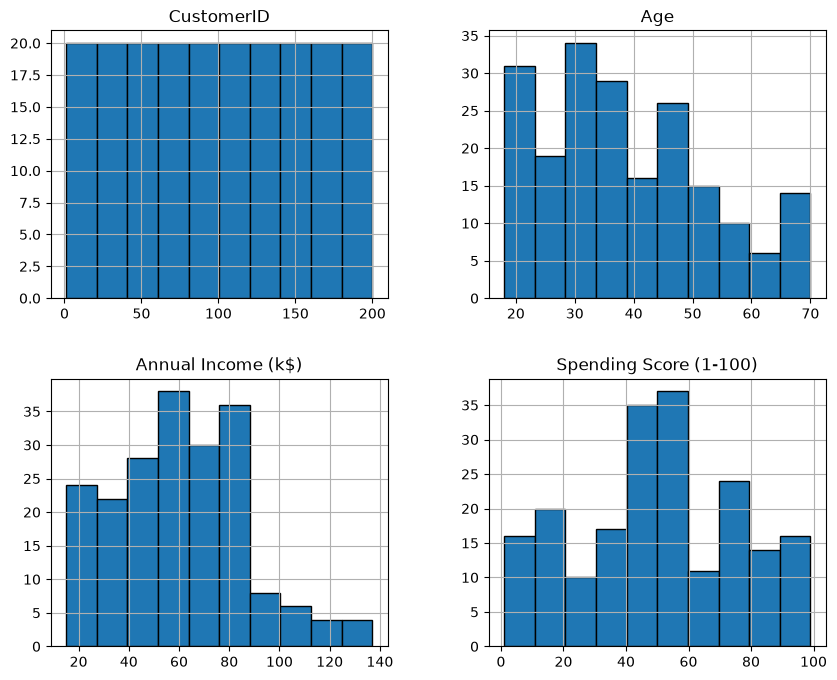

In [8]:
df.hist(figsize=(10,8),edgecolor='black')
plt.show()

<Axes: xlabel='Genre', ylabel='count'>

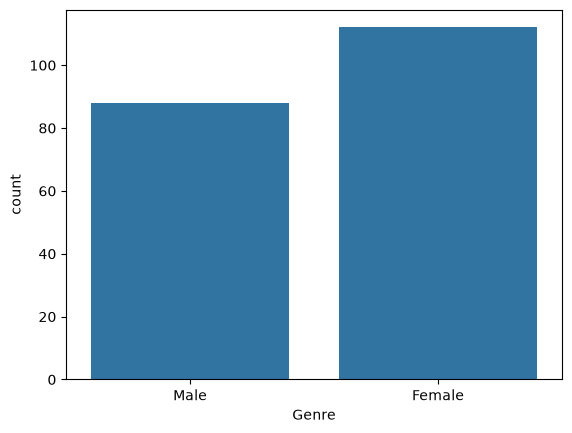

In [9]:
sns.countplot(x='Genre',data=df)

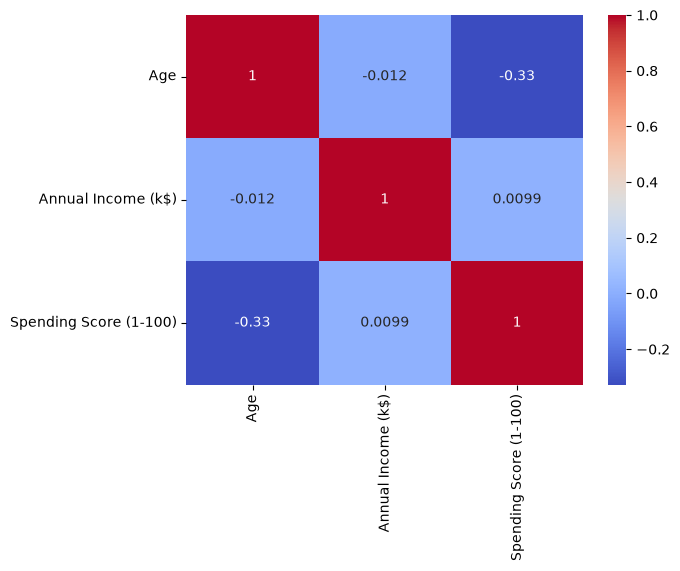

In [10]:
numeric = df.drop(["CustomerID","Genre"], axis=1)

sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")
plt.show()

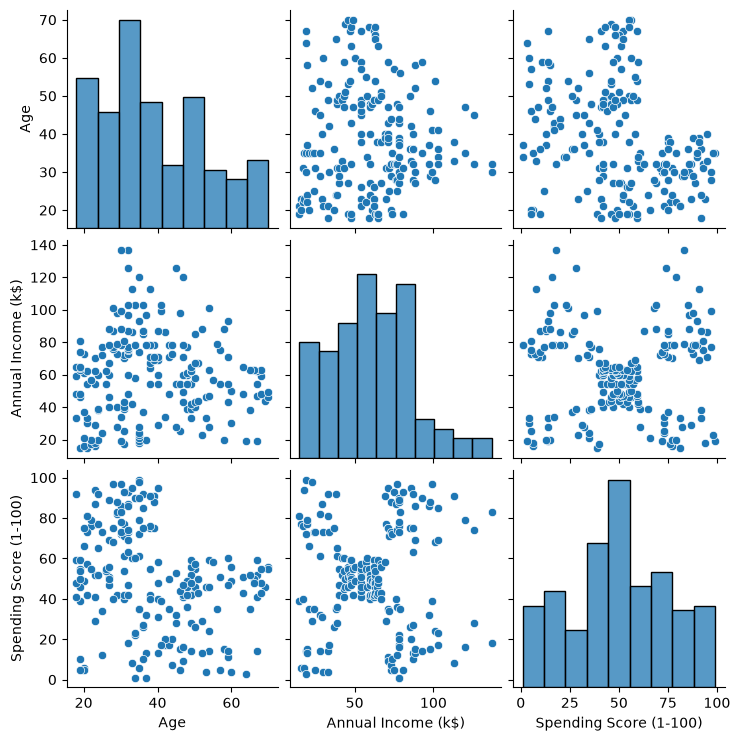

In [11]:
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.show()

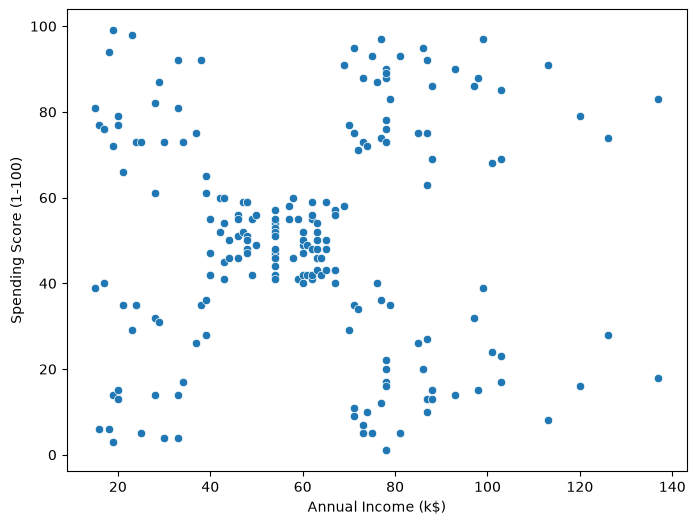

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df
)

plt.show()

In [13]:
X = df[["Annual Income (k$)",
        "Spending Score (1-100)"]]

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

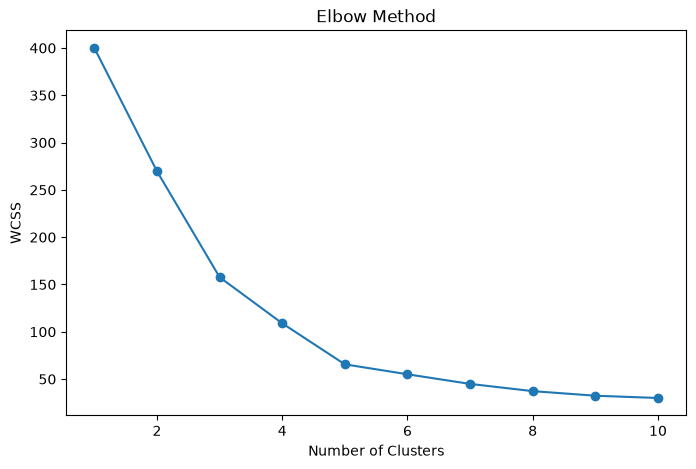

In [16]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [17]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = labels

In [18]:
kmeans.cluster_centers_

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [19]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

print(centers)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


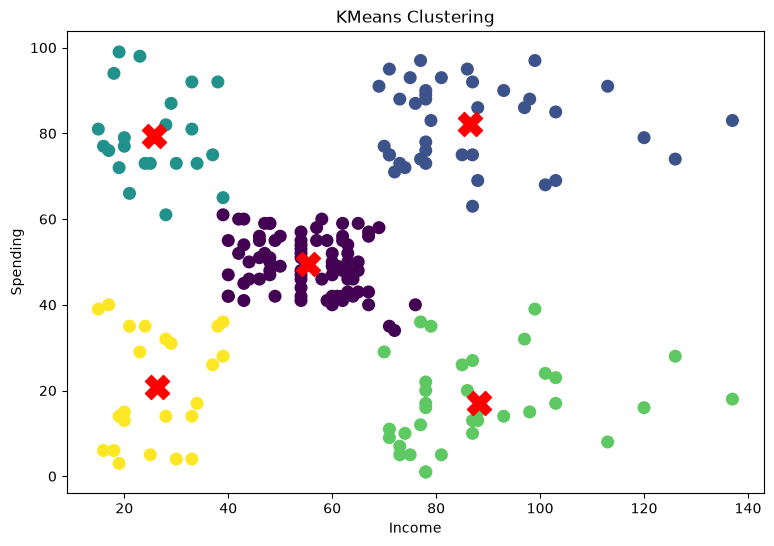

In [20]:
plt.figure(figsize=(9,6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=labels,
    cmap="viridis",
    s=70
)

centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:,0],
    centers[:,1],
    color='red',
    marker='X',
    s=300
)

plt.xlabel("Income")

plt.ylabel("Spending")

plt.title("KMeans Clustering")

plt.show()

In [21]:
#Evaluate KMeans
score = silhouette_score(X_scaled, labels)

print(score)

0.5546571631111091


In [22]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

In [23]:
np.unique(db_labels)

array([-1,  0,  1])

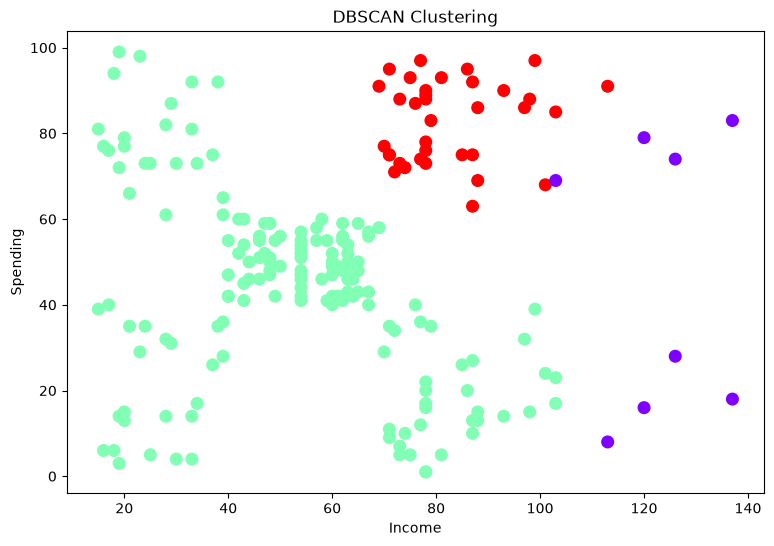

In [24]:
plt.figure(figsize=(9,6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=db_labels,
    cmap="rainbow",
    s=70
)

plt.xlabel("Income")
plt.ylabel("Spending")

plt.title("DBSCAN Clustering")

plt.show()

In [25]:
#Evaluate DBSCAN
mask = db_labels != -1

score = silhouette_score(
    X_scaled[mask],
    db_labels[mask]
)

print(score)

0.3875583892728279
